In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data = pd.read_csv('campaign_data.csv')

In [4]:
data.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CampaignID   10000 non-null  str    
 1   StartDate    10000 non-null  str    
 2   EndDate      10000 non-null  str    
 3   Channel      10000 non-null  str    
 4   Impressions  10000 non-null  int64  
 5   Clicks       10000 non-null  int64  
 6   Leads        10000 non-null  int64  
 7   Conversions  10000 non-null  int64  
 8   Cost_USD     10000 non-null  float64
 9   Revenue_USD  10000 non-null  float64
 10  ROI          10000 non-null  float64
dtypes: float64(3), int64(4), str(4)
memory usage: 859.5 KB


In [6]:
data.shape

(10000, 11)

In [7]:
data.describe()

,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,152260.637900,8338.993300,2512.463600,1010.700000,2552.356991,5102.648930,1.001576
std,85251.707621,6546.326431,2321.031302,1019.402613,1427.694545,3309.326705,0.578806
min,5043.000000,72.000000,10.000000,4.000000,100.230000,113.640000,0.000000
25%,78956.000000,2981.000000,779.000000,295.000000,1319.622500,2385.742500,0.500000
50%,151505.500000,6588.500000,1777.000000,670.000000,2529.675000,4659.365000,0.990000
75%,225853.250000,12404.250000,3550.250000,1391.000000,3821.307500,7241.245000,1.510000
max,299997.000000,29578.000000,13833.000000,7987.000000,4998.420000,14871.340000,2.000000


In [8]:
data.duplicated().sum()

np.int64(0)

Changing StartDate and EndDate to DateTime and making a Duration column

In [9]:
data[['StartDate', 'EndDate']] = data[['StartDate', 'EndDate']].apply(pd.to_datetime)
data['Duration'] = data['EndDate'] - data['StartDate']

Making a ConversionRate column from Conversions and Leads

In [10]:
data['ConversionRate'] = data['Conversions'] / data['Leads']

Making a ClickRate column with Clicks and Impressions

In [11]:
data['ClickRate'] = data['Clicks'] / data['Impressions']

In [12]:
data['StartMonth'] = data['StartDate'].dt.month_name()

Reordering the new columns

In [13]:
cols = list(data.columns)
cols.insert(2, cols.pop(cols.index('StartMonth')))
cols.insert(4, cols.pop(cols.index('Duration')))
cols.insert(8, cols.pop(cols.index('ClickRate')))
cols.insert(11, cols.pop(cols.index('ConversionRate')))
data = data[cols]
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   CampaignID      10000 non-null  str            
 1   StartDate       10000 non-null  datetime64[us] 
 2   StartMonth      10000 non-null  str            
 3   EndDate         10000 non-null  datetime64[us] 
 4   Duration        10000 non-null  timedelta64[us]
 5   Channel         10000 non-null  str            
 6   Impressions     10000 non-null  int64          
 7   Clicks          10000 non-null  int64          
 8   ClickRate       10000 non-null  float64        
 9   Leads           10000 non-null  int64          
 10  Conversions     10000 non-null  int64          
 11  ConversionRate  10000 non-null  float64        
 12  Cost_USD        10000 non-null  float64        
 13  Revenue_USD     10000 non-null  float64        
 14  ROI             10000 non-null  float64        
dt

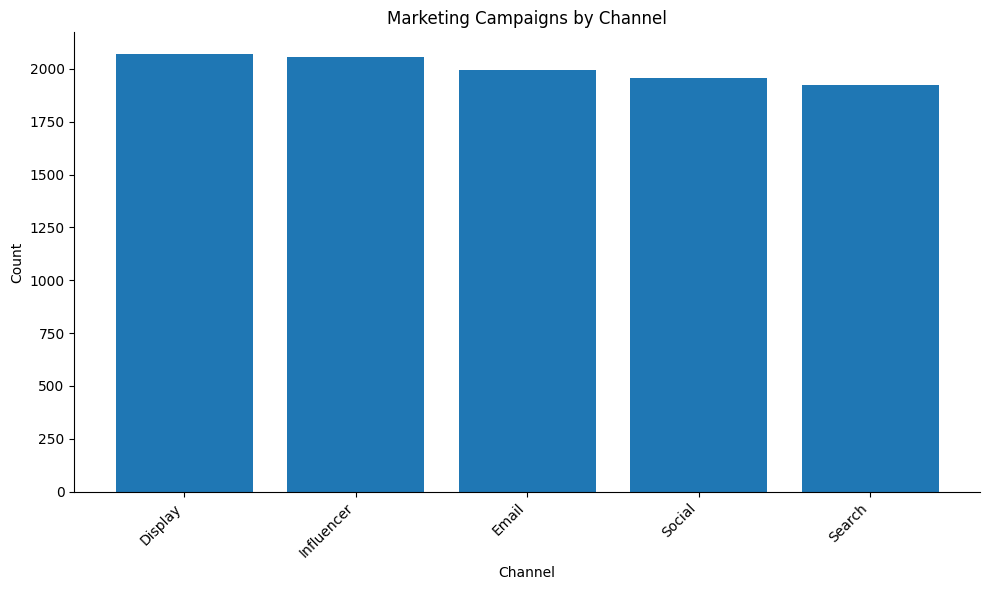

In [14]:
channel_counts = data['Channel'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(channel_counts.index, channel_counts.values)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Channel')
plt.ylabel('Count')
plt.title("Marketing Campaigns by Channel")
plt.xticks(rotation=45, ha='right')


plt.tight_layout()
plt.show()


In [15]:
avg_ROI = data.groupby('Channel')['ROI'].mean().sort_values(ascending=False)
avg_ROI

Channel
Search        1.013389
Email         1.009990
Display       0.999304
Influencer    0.997529
Social        0.988020
Name: ROI, dtype: float64

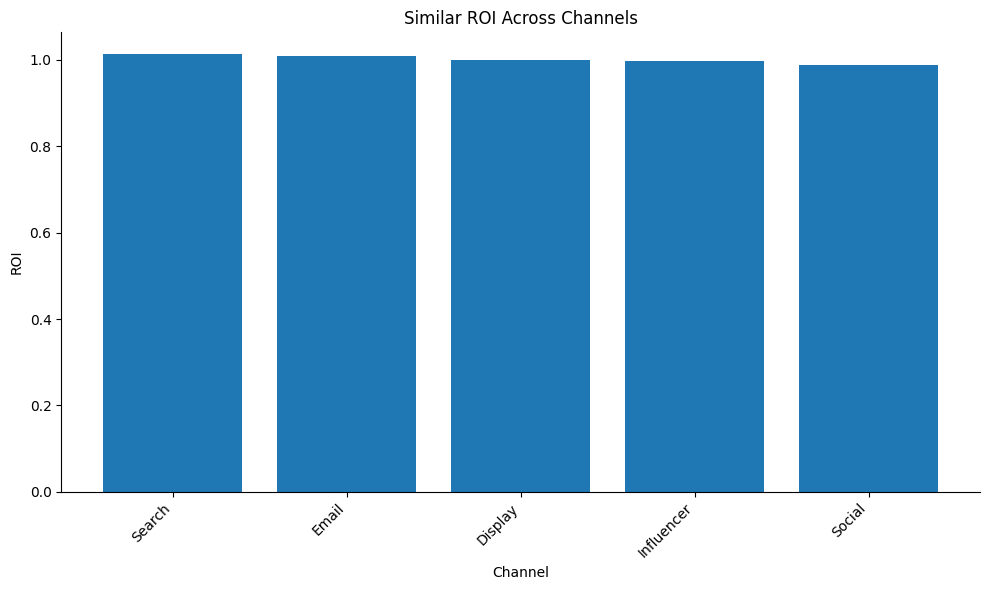

In [16]:
plt.figure(figsize=(10,6))
plt.bar(avg_ROI.index, avg_ROI.values)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Channel')
plt.ylabel('ROI')
plt.title("Similar ROI Across Channels")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

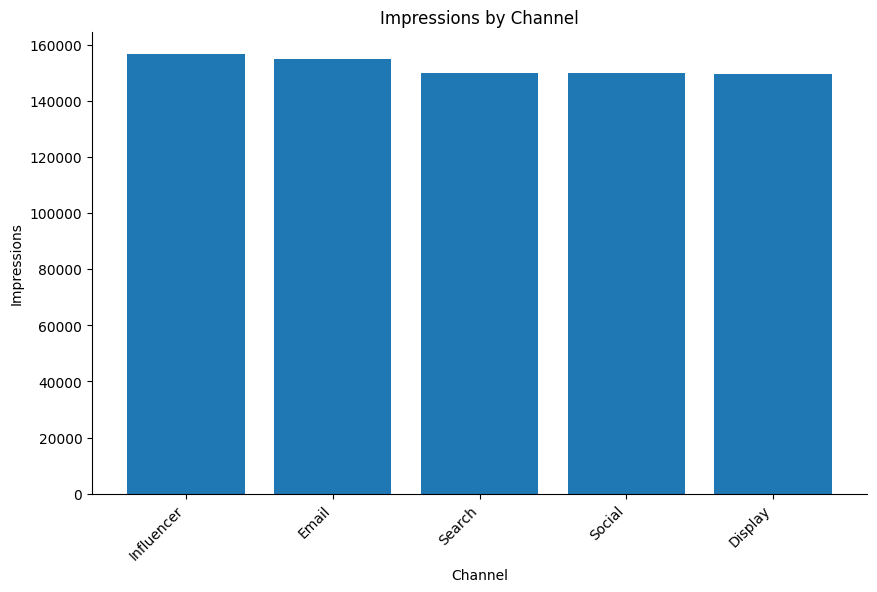

In [17]:
avg_Impressions = data.groupby('Channel')['Impressions'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(avg_Impressions.index, avg_Impressions.values)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Channel')
plt.ylabel('Impressions')
plt.title("Impressions by Channel")
plt.xticks(rotation=45, ha='right')

plt.show()

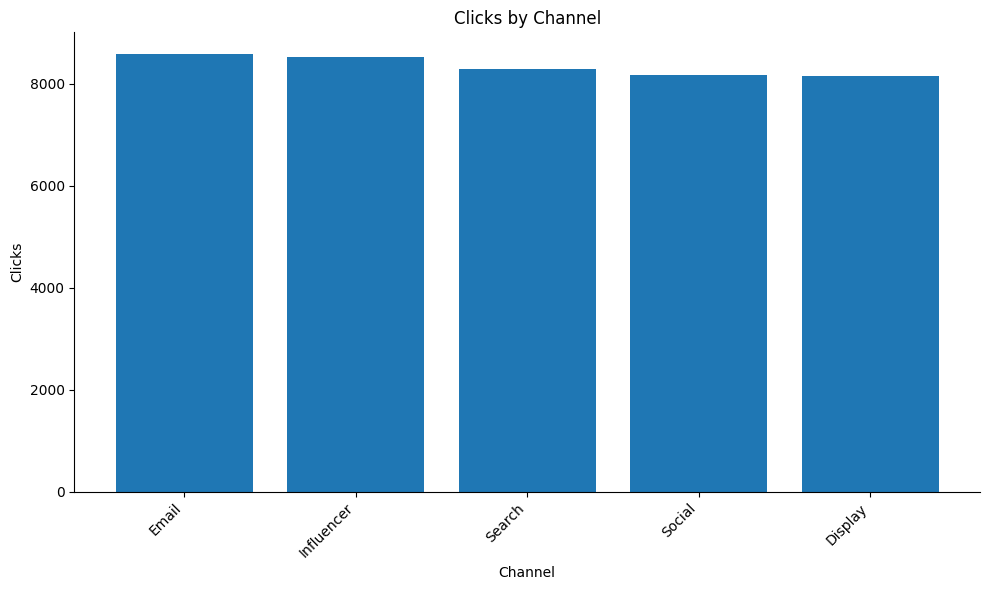

In [18]:
avg_Clicks = data.groupby('Channel')['Clicks'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(avg_Clicks.index, avg_Clicks.values)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Channel')
plt.ylabel('Clicks')
plt.title("Clicks by Channel")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

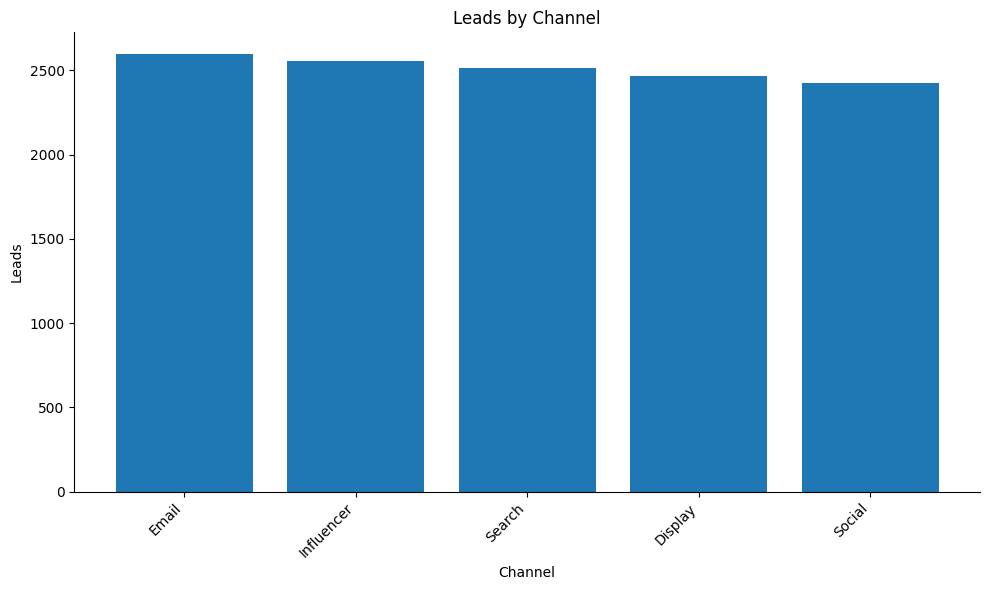

In [19]:
avg_Leads = data.groupby('Channel')['Leads'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(avg_Leads.index, avg_Leads.values)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Channel')
plt.ylabel('Leads')
plt.title('Leads by Channel')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

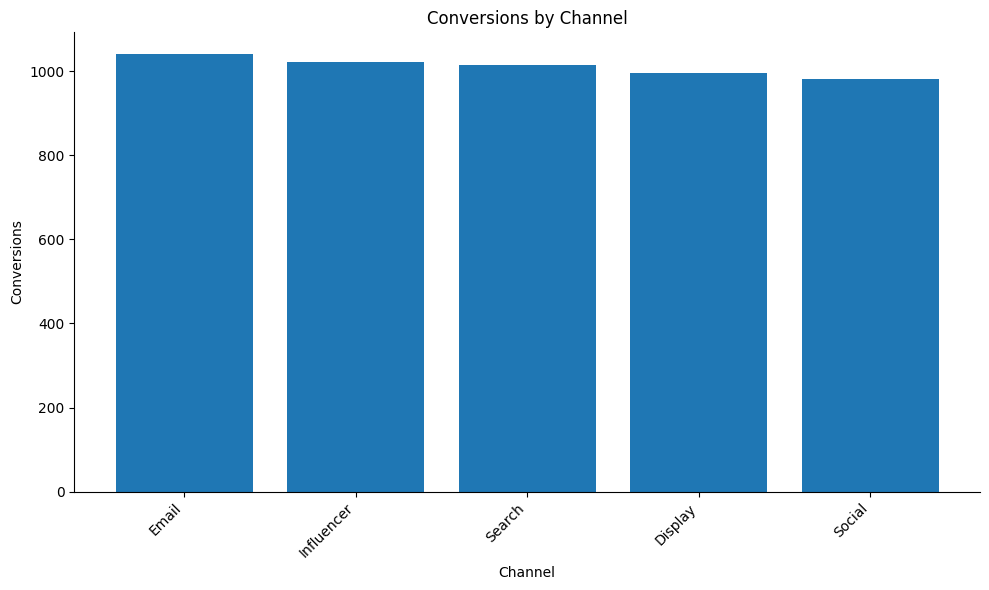

In [20]:
avg_Conversions = data.groupby('Channel')['Conversions'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(avg_Conversions.index, avg_Conversions.values)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Channel')
plt.ylabel('Conversions')
plt.title('Conversions by Channel')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   CampaignID      10000 non-null  str            
 1   StartDate       10000 non-null  datetime64[us] 
 2   StartMonth      10000 non-null  str            
 3   EndDate         10000 non-null  datetime64[us] 
 4   Duration        10000 non-null  timedelta64[us]
 5   Channel         10000 non-null  str            
 6   Impressions     10000 non-null  int64          
 7   Clicks          10000 non-null  int64          
 8   ClickRate       10000 non-null  float64        
 9   Leads           10000 non-null  int64          
 10  Conversions     10000 non-null  int64          
 11  ConversionRate  10000 non-null  float64        
 12  Cost_USD        10000 non-null  float64        
 13  Revenue_USD     10000 non-null  float64        
 14  ROI             10000 non-null  float64        
dt

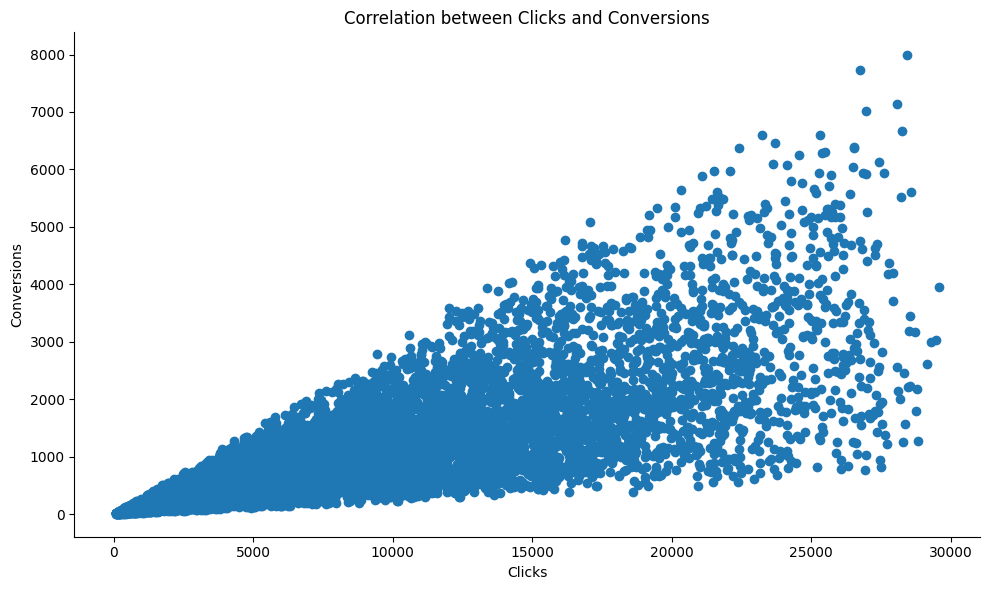

In [22]:
plt.figure(figsize=(10,6))
plt.scatter(
    data['Clicks'], 
    data['Conversions'])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Clicks')
plt.ylabel('Conversions')
plt.title('Correlation between Clicks and Conversions')

plt.tight_layout()
plt.show()

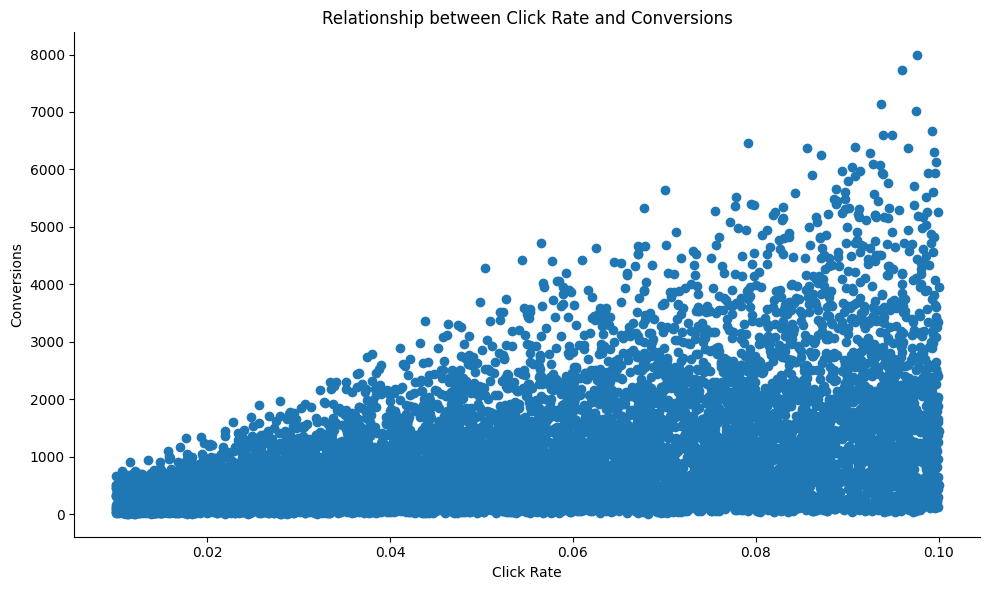

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(
    data['ClickRate'], 
    data['Conversions'])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Click Rate')
plt.ylabel('Conversions')
plt.title('Relationship between Click Rate and Conversions')

plt.tight_layout()
plt.show()

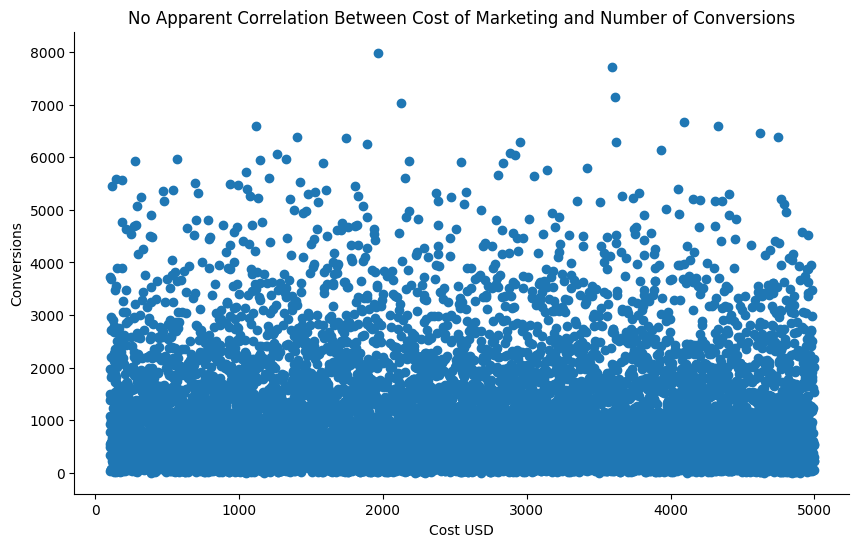

In [24]:
plt.figure(figsize=(10,6))
plt.scatter(
    data['Cost_USD'], 
    data['Conversions'])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Cost USD')
plt.ylabel('Conversions')
plt.title('No Apparent Correlation Between Cost of Marketing and Number of Conversions')

plt.show()

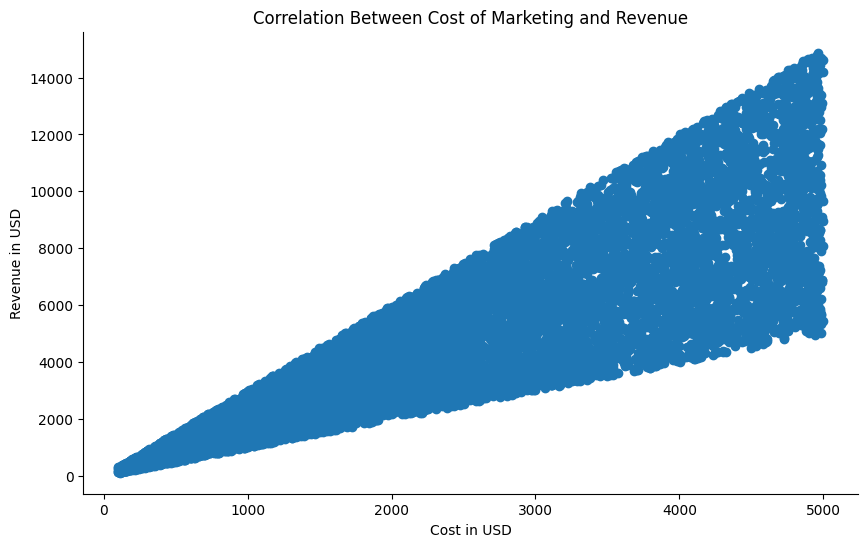

In [25]:
plt.figure(figsize=(10,6))
plt.scatter(
    data['Cost_USD'],
    data['Revenue_USD'])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Cost in USD')
plt.ylabel('Revenue in USD')
plt.title('Correlation Between Cost of Marketing and Revenue')

plt.show()

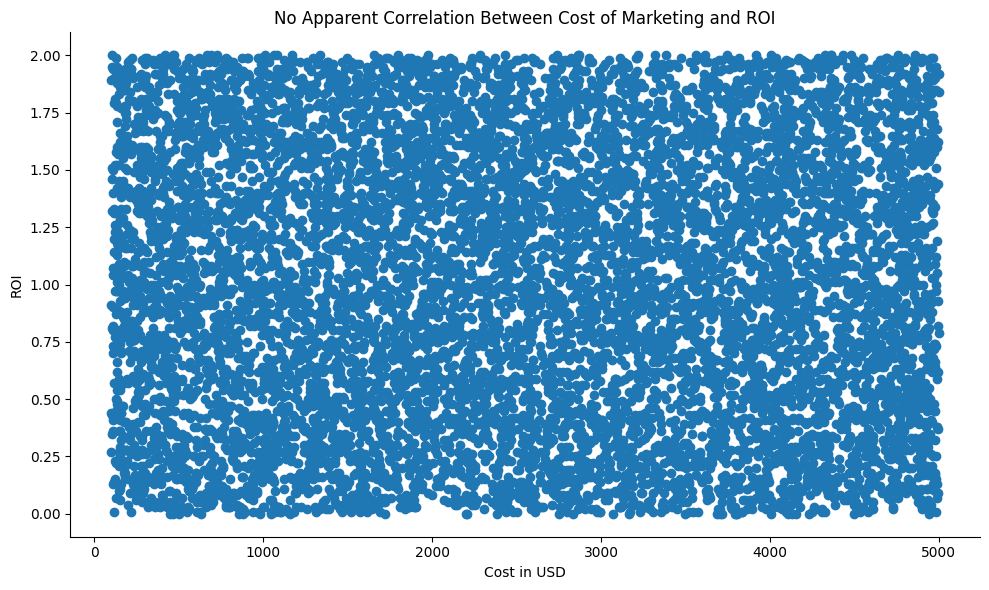

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(
    data['Cost_USD'],
    data['ROI'])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylabel('ROI')
plt.xlabel('Cost in USD')
plt.title('No Apparent Correlation Between Cost of Marketing and ROI')

plt.tight_layout()
plt.show()

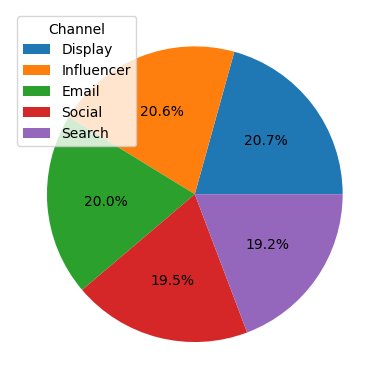

<Figure size 1000x1000 with 0 Axes>

In [ ]:
plt.pie(channel_counts,
        autopct='%1.1f%%')

plt.legend(labels = channel_counts.index,
           loc='upper left',
           title='Channel')

plt.figure(figsize=(10,10))
plt.show()

In [28]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg = data['StartMonth'].value_counts().reindex(month_order)
monthly_avg

StartMonth
January      859
February     759
March        824
April        865
May          864
June         841
July         838
August       857
September    778
October      837
November     838
December     840
Name: count, dtype: int64

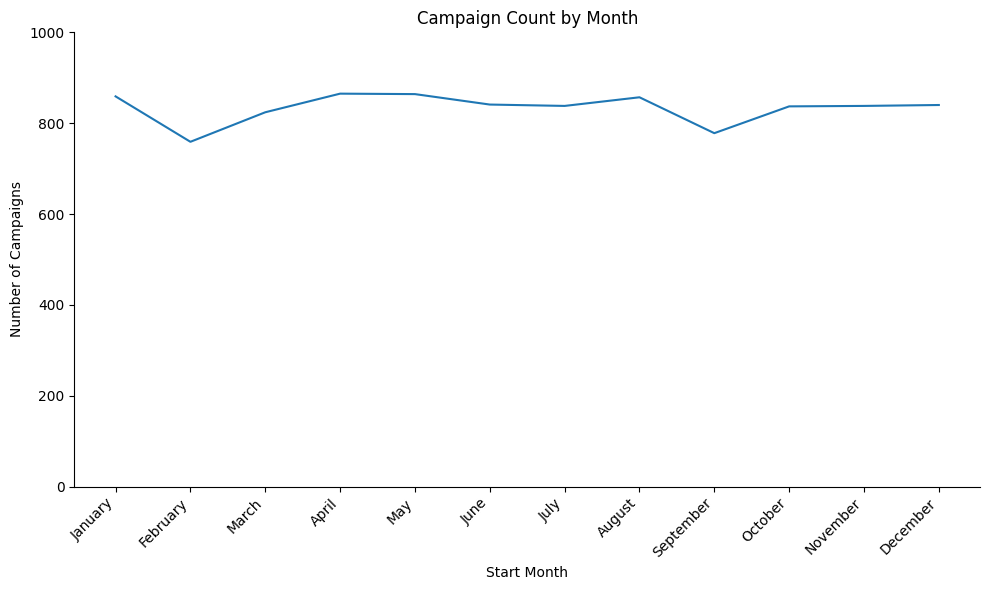

In [29]:
plt.figure(figsize=(10,6))
plt.plot(monthly_avg)
plt.ylim(bottom = 0,
         top = 1000)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Campaign Count by Month')
plt.xlabel('Start Month')
plt.ylabel('Number of Campaigns')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

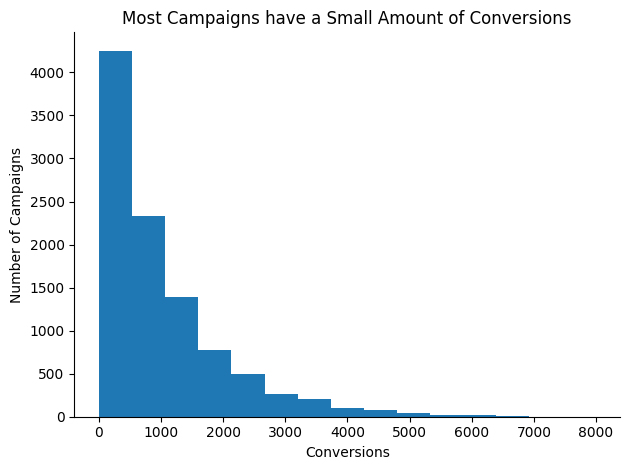

In [30]:
plt.hist(
    data['Conversions'],
    bins=15)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Conversions')
plt.ylabel('Number of Campaigns')
plt.title('Most Campaigns have a Small Amount of Conversions')

plt.tight_layout()
plt.show()

In [31]:
data['Cost_USD'].describe()

count    10000.000000
mean      2552.356991
std       1427.694545
min        100.230000
25%       1319.622500
50%       2529.675000
75%       3821.307500
max       4998.420000
Name: Cost_USD, dtype: float64

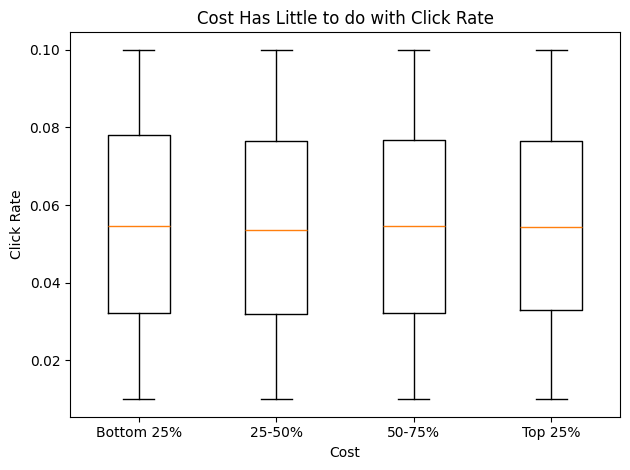

In [32]:
plt.boxplot(
    [data[data["Cost_USD"] <= 1319.62]['ClickRate'],
    data[(data["Cost_USD"] > 1319.62) & (data["Cost_USD"] <= 2529.67)]['ClickRate'],
    data[(data["Cost_USD"] > 2529.67) & (data["Cost_USD"] <= 3821.30)]['ClickRate'],
    data[data["Cost_USD"] > 3821.30]['ClickRate']]
)

plt.xticks([1,2,3,4],['Bottom 25%', '25-50%', '50-75%', 'Top 25%'])
plt.xlabel('Cost')
plt.ylabel('Click Rate')
plt.title('Cost Has Little to do with Click Rate')

plt.tight_layout()
plt.show()

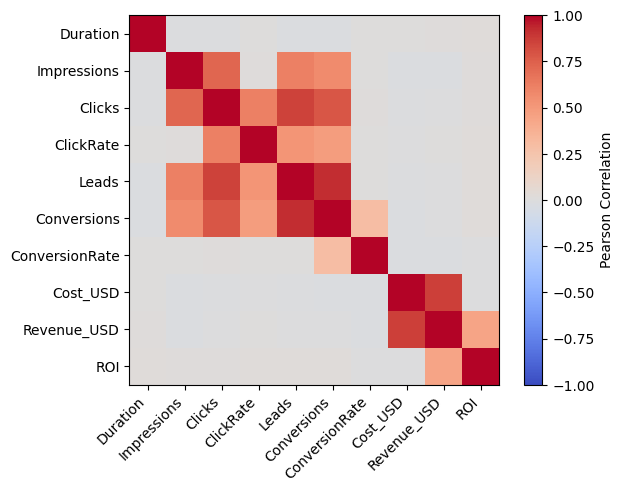

In [33]:
numeric_df = data.select_dtypes(include=[np.number])
corr = numeric_df.corr()

im = plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(im, label='Pearson Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()